# 816037651 David Williams
# Assignment 2: ML Model Training & Evaluation 
# Part 1: Data Preprocessing & Feature Engineering

## 1.1 Introduction

The objective of this assignment is to build and evaluate machine learning models to:  
* Predict the tip_amount for a taxi trip (regression task).  
* Pedict whether a trip receives a high tip (>20% of fare amount) (classification task).  
* Following the assignment instructions, only credit card transactions (payment_type = 1) are used, as tip amounts are reliably recorded only for these transactions.

All experiments use random_state=42 to ensure reproducibility.  

This assignment was tested locally using jupyterlab on a Lenovo ideapad 5 pro

## 1.2 Imports and Reproducibility

In [1]:
# Core libraries
import os
import requests
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# SHAP
import shap

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

#### Download Raw Taxi Dataset

In [2]:
DATA_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
DATA_PATH = "yellow_tripdata_2023-01.parquet"

if not os.path.exists(DATA_PATH):
    print("Downloading NYC Taxi dataset...")
    r = requests.get(DATA_URL)
    with open(DATA_PATH, "wb") as f:
        f.write(r.content)
    print("Download complete.")
else:
    print("Dataset already exists.")

Dataset already exists.


#### Download Taxi Zone Lookup Table

In [3]:
ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv"
ZONE_PATH = "taxi_zone_lookup.csv"

if not os.path.exists(ZONE_PATH):
    print("Downloading Taxi Zone Lookup...")
    r = requests.get(ZONE_URL)
    with open(ZONE_PATH, "wb") as f:
        f.write(r.content)
    print("Zone lookup download complete.")
else:
    print("Zone lookup already exists.")

Zone lookup already exists.


#### Load Raw Data

In [4]:
df = pd.read_parquet(DATA_PATH)

print("Raw dataset shape:", df.shape)
df.head()

Raw dataset shape: (3066766, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


#### Data Cleaning
Select Relevant Columns

In [5]:
columns_needed = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "total_amount",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]

df = df[columns_needed].copy()

#### Rename Columns for Consistency

In [6]:
df.rename(columns={
    "tpep_pickup_datetime": "pickup_datetime",
    "tpep_dropoff_datetime": "dropoff_datetime"
}, inplace=True)

#### Basic Cleaning Rules

Removes:
* Negative/zero distances and fares (clearly erroneous entries)
* Trips where dropoff time is before pickup time (impossible)
* The top 1% of fares and distances (extreme outliers that would skew models)

In [7]:
# Remove negative or zero trip distances
df = df[df["trip_distance"] > 0]

# Remove negative fares
df = df[df["fare_amount"] > 0]

# Remove negative tip amounts
df = df[df["tip_amount"] >= 0]

# Remove trips with invalid timestamps
df = df[df["dropoff_datetime"] > df["pickup_datetime"]]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (2998306, 13)


#### Remove Extreme Outliers

In [8]:
# Remove extreme fare outliers
df = df[df["fare_amount"] < df["fare_amount"].quantile(0.99)]

# Remove extreme distance outliers
df = df[df["trip_distance"] < df["trip_distance"].quantile(0.99)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (2937653, 13)


#### Save Cleaned Version

In [9]:
CLEANED_PATH = "cleaned_taxi_data.csv"

df.to_csv(CLEANED_PATH, index=False)

print("Cleaned dataset saved locally.")

Cleaned dataset saved locally.


## 1.3 Data Loading & Filtering

In [10]:
# Filter to credit card transactions
df = df[df["payment_type"] == 1].copy()

print(f"Dataset size after credit card filtering: {df.shape[0]:,} rows")

Dataset size after credit card filtering: 2,342,905 rows


Why only credit card transactions?  
Cash tips aren't recorded in the system, so the tip_amount column is only reliable for card payments. Filtering to payment_type == 1 gives about 2.3 million usable rows.

## 1.4 Feature Engineering

#### Temporal Features:
* pickup hour
* day of week
* is it a weekend? (tipping patterns differ by time)

In [11]:
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_day_of_week"] = df["pickup_datetime"].dt.dayofweek
df["is_weekend"] = df["pickup_day_of_week"].isin([5, 6]).astype(int)

#### Trip Features:
* duration in minutes
* speed in mph
* log of distance (log makes skewed distributions more normal)

In [12]:
df["trip_duration_minutes"] = (
    df["dropoff_datetime"] - df["pickup_datetime"]
).dt.total_seconds() / 60

df["trip_speed_mph"] = df["trip_distance"] / (df["trip_duration_minutes"] / 60)
df["trip_speed_mph"] = df["trip_speed_mph"].replace([np.inf, -np.inf], np.nan)

df["log_trip_distance"] = np.log1p(df["trip_distance"])

#### Fare Features
* fare per mile
* fare per minute (efficiency ratios)

In [13]:
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"].replace(0, np.nan)
df["fare_per_minute"] = df["fare_amount"] / df["trip_duration_minutes"].replace(0, np.nan)

#### Borough Encoding:  
pickup/dropoff neighbourhood converted to dummy variables (0/1 columns)

In [14]:
zones = pd.read_csv("taxi_zone_lookup.csv")

df = df.merge(
    zones[["LocationID", "Borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename(columns={"Borough": "pickup_borough"}).drop(columns=["LocationID"])

df = df.merge(
    zones[["LocationID", "Borough"]],
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
).rename(columns={"Borough": "dropoff_borough"}).drop(columns=["LocationID"])

df = pd.get_dummies(df, columns=["pickup_borough", "dropoff_borough"], drop_first=True)

## 1.5 Target Variables
#### Regression Target (Log-Transformed)  
The tip amount with a log transformation applied, because tip amounts are right-skewed (most tips are small, a few are huge). Log-transforming stabilizes this.

In [15]:
df["log_tip_amount"] = np.log1p(df["tip_amount"])

#### Classification Target  
a 1/0 flag: did the tip exceed 20% of the fare?

In [16]:
df["high_tip"] = (df["tip_amount"] > 0.20 * df["fare_amount"]).astype(int)

## 1.6 Feature Selection

#### Leakage Prevention  
For classification, fare_amount, fare_per_mile, and fare_per_minute were removed. Why? Because at prediction time (when a trip starts), you don't yet know the final fare. More importantly, fare amount is mathematically used to define high_tip, so including it would be cheating as the model would learn a trivial relationship rather than anything meaningful.

In [17]:
exclude_cols = [
    "pickup_datetime", "dropoff_datetime",
    "tip_amount", "log_tip_amount",
    "high_tip", "total_amount",
    "payment_type"
]

# Regression Features (keep monetary features)
X_reg = df.drop(columns=exclude_cols)
y_reg = df["log_tip_amount"]

# Classification Features (REMOVE monetary leakage)
leakage_cols = [
    "fare_amount",
    "fare_per_mile",
    "fare_per_minute"
]

X_clf = X_reg.drop(columns=leakage_cols)
y_clf = df["high_tip"]

## 1.7 Train / Validation / Test Split (70/15/15)

The data is split three ways:  
* Training set — model learns from this
* Validation set — used to tune and compare models without touching test data
* Test set — final, untouched evaluation  

Classification uses stratification, meaning each split maintains the same class ratio (~75% high tip, ~25% not). Without this, by random chance you could get imbalanced splits.

In [18]:
# Regression Split
X_reg_train, X_reg_temp, y_reg_train, y_reg_temp = train_test_split(
    X_reg, y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE
)

X_reg_val, X_reg_test, y_reg_val, y_reg_test = train_test_split(
    X_reg_temp, y_reg_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

# Classification Split (stratified)
X_clf_train, X_clf_temp, y_clf_train, y_clf_temp = train_test_split(
    X_clf, y_clf,
    test_size=0.30,
    stratify=y_clf,
    random_state=RANDOM_STATE
)

X_clf_val, X_clf_test, y_clf_val, y_clf_test = train_test_split(
    X_clf_temp, y_clf_temp,
    test_size=0.50,
    stratify=y_clf_temp,
    random_state=RANDOM_STATE
)

print("Classification Class Distribution:")
print(y_clf_train.value_counts(normalize=True))


# 1.7 Train / Validation / Test Split (70/15/15)
# Print split sizes (Requirement 3c)
print(f"Training set: {len(X_clf_train)} samples")
print(f"Validation set: {len(X_clf_val)} samples")
print(f"Test set: {len(X_clf_test)} samples\n")

# Document class distribution in EACH split (Requirement 3c)
for name, y_split in [("Train", y_clf_train), ("Val", y_clf_val), ("Test", y_clf_test)]:
    dist = y_split.value_counts(normalize=True)
    print(f"{name} Class Distribution:\n{dist}\n")

# Summary of excluded features (Requirement 3d)
print("Excluded Features Summary:")
print("- pickup_datetime/dropoff_datetime: Redundant after temporal feature extraction.")
print("- payment_type: Filtered to '1' (Credit Card), so it has zero variance.")
print("- total_amount: Contains the target (tip_amount), causing data leakage.")

Classification Class Distribution:
high_tip
1    0.752072
0    0.247928
Name: proportion, dtype: float64
Training set: 1640033 samples
Validation set: 351436 samples
Test set: 351436 samples

Train Class Distribution:
high_tip
1    0.752072
0    0.247928
Name: proportion, dtype: float64

Val Class Distribution:
high_tip
1    0.752072
0    0.247928
Name: proportion, dtype: float64

Test Class Distribution:
high_tip
1    0.752072
0    0.247928
Name: proportion, dtype: float64

Excluded Features Summary:
- pickup_datetime/dropoff_datetime: Redundant after temporal feature extraction.
- payment_type: Filtered to '1' (Credit Card), so it has zero variance.
- total_amount: Contains the target (tip_amount), causing data leakage.


## 1.8 Leakage-Proof Preprocessing Pipeline

Before training, numeric features go through:
* Imputation: fills missing values with the median
* Scaling: standardizes values to mean=0, std=1 (important for linear models; distance shouldn't dominate just because it's in larger units than hour)  

Borough dummy columns are passed through unchanged since they're already 0/1.  
The pipeline ensures this preprocessing is fit only on training data and then applied to validation/test — preventing data leakage.  

In [19]:
# Preprocessing for Regression
numeric_features_reg = X_reg.select_dtypes(include=np.number).columns
categorical_features_reg = [col for col in X_reg.columns if "borough" in col]

numeric_pipeline_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_reg = ColumnTransformer([
    ("num", numeric_pipeline_reg, numeric_features_reg),
    ("cat", "passthrough", categorical_features_reg)
])


# Preprocessing for Classification
numeric_features_clf = X_clf.select_dtypes(include=np.number).columns
categorical_features_clf = [col for col in X_clf.columns if "borough" in col]

numeric_pipeline_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_clf = ColumnTransformer([
    ("num", numeric_pipeline_clf, numeric_features_clf),
    ("cat", "passthrough", categorical_features_clf)
])

# Part 2: Model Training & Tuning
## 2.1 Baseline Regression Models

Linear Regression: Fits a straight-line relationship between features and tip  
Random Forest: Builds many decision trees, averages their predictions

In [20]:
# 2.1 Baseline Regression Models

lin_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", LinearRegression())
])

rf_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lin_reg_pipeline.fit(X_reg_train, y_reg_train)
rf_reg_pipeline.fit(X_reg_train, y_reg_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

#### Validation Evaluation

In [21]:
def evaluate_regression(model, X, y_log):
    y_pred_log = model.predict(X)
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_log)

    return {
        "MAE": mean_absolute_error(y_actual, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_actual, y_pred)),
        "R2": r2_score(y_actual, y_pred)
    }

print("Linear Regression:",
      evaluate_regression(lin_reg_pipeline, X_reg_val, y_reg_val))

print("Random Forest:",
      evaluate_regression(rf_reg_pipeline, X_reg_val, y_reg_val))

Linear Regression: {'MAE': 1.3517842196138579, 'RMSE': np.float64(2.1915043723285903), 'R2': 0.5544801124840611}
Random Forest: {'MAE': 1.3578549104073347, 'RMSE': np.float64(2.232799228003672), 'R2': 0.5375319239712864}


## 2.2 Baseline Classification Models

Logistic Regression: Estimates probability of high tip using a sigmoid function  
Random Forest: Same ensemble approach, but predicts class probabilities

In [22]:
# 2.2 Baseline Classification Models

log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor_clf),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

rf_clf_pipeline = Pipeline([
    ("preprocessor", preprocessor_clf),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

log_reg_pipeline.fit(X_clf_train, y_clf_train)
rf_clf_pipeline.fit(X_clf_train, y_clf_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

#### Validation Evaluation

In [23]:
def evaluate_classification(model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:,1]

    return {
        "Accuracy": accuracy_score(y, preds),
        "Precision": precision_score(y, preds),
        "Recall": recall_score(y, preds),
        "F1": f1_score(y, preds),
        "AUC": roc_auc_score(y, probs)
    }

print("Logistic Regression:",
      evaluate_classification(log_reg_pipeline, X_clf_val, y_clf_val))

print("Random Forest:",
      evaluate_classification(rf_clf_pipeline, X_clf_val, y_clf_val))

Logistic Regression: {'Accuracy': 0.7535198442959742, 'Precision': 0.7542782072601442, 'Recall': 0.9970866990787158, 'F1': 0.8588510197297667, 'AUC': 0.5923742576164783}
Random Forest: {'Accuracy': 0.750899167985067, 'Precision': 0.7589949772305024, 'Recall': 0.9799436257354193, 'F1': 0.8554324904095609, 'AUC': 0.5819505093602322}


## 2.3 Hyperparameter Tuning (200,000 Row Sample)

RandomizedSearchCV randomly samples combinations of parameters (like tree depth, number of trees) and uses 5-fold cross-validation to evaluate each. It tests 20 combinations on a 200k sample (subset used to save time/memory). 

In [24]:
sample_size = 200000  # reduce to avoid RAM explosion
sample_idx = np.random.choice(len(X_clf_train), sample_size, replace=False)

param_dist = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [None, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    rf_clf_pipeline,
    param_distributions=param_dist,
    n_iter=20,              # reduce search space
    cv=5,                  # reduce folds
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    #n_jobs=1,  # Use all cores # Prevents memory spikes by limiting queued tasks
    n_jobs=2,               # <--- Changed from -1. Try 2 first, then 3 if stable.
    pre_dispatch='n_jobs',  # <--- Strictly limit memory queue
    verbose=2
)

random_search.fit(
    X_clf_train.iloc[sample_idx],
    y_clf_train.iloc[sample_idx]
)

best_rf_clf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Tuned RF Performance:", evaluate_classification(best_rf_clf, X_clf_val, y_clf_val))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 40}
Tuned RF Performance: {'Accuracy': 0.711862188278947, 'Precision': 0.7711788010737844, 'Recall': 0.8771343712756097, 'F1': 0.8207511098838074, 'AUC': 0.5955848493338952}


## 2.4 Neural Network (Classification)

A PyTorch neural network with this architecture:
Input → 256 neurons → 128 → 64 → 1 output

BatchNorm (stabilizes training)
Dropout (prevents overfitting)
ReLU activations (introduces nonlinearity)

In [25]:
class TaxiNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.layers(x)

#### Prepare Data

In [26]:
X_train_transformed = preprocessor_clf.fit_transform(X_clf_train)
X_val_transformed = preprocessor_clf.transform(X_clf_val)

X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_clf_train.values, dtype=torch.float32).view(-1,1)

X_val_tensor = torch.tensor(X_val_transformed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_clf_val.values, dtype=torch.float32).view(-1,1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=256, shuffle=True)

val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor),
                        batch_size=256)

#### Training Loop

It uses BCEWithLogitsLoss with pos_weight to handle class imbalance. Since ~75% of trips are "high tip," the model could just predict everything as high tip and be 75% accurate. The pos_weight penalizes it more for missing the minority class.

In [27]:
model = TaxiNN(X_train_transformed.shape[1])
pos_weight = torch.tensor(
    (y_clf_train == 0).sum() / (y_clf_train == 1).sum(),
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)

train_losses, val_losses = [], []

for epoch in range(25):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_losses.append(train_loss / len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Val {val_losses[-1]:.4f}")

Epoch 1: Train 0.3364, Val 0.3353
Epoch 2: Train 0.3355, Val 0.3351
Epoch 3: Train 0.3352, Val 0.3347
Epoch 4: Train 0.3350, Val 0.3347
Epoch 5: Train 0.3349, Val 0.3347
Epoch 6: Train 0.3348, Val 0.3347
Epoch 7: Train 0.3348, Val 0.3347
Epoch 8: Train 0.3347, Val 0.3344
Epoch 9: Train 0.3347, Val 0.3344
Epoch 10: Train 0.3346, Val 0.3343
Epoch 11: Train 0.3346, Val 0.3343
Epoch 12: Train 0.3346, Val 0.3345
Epoch 13: Train 0.3346, Val 0.3344
Epoch 14: Train 0.3345, Val 0.3344
Epoch 15: Train 0.3345, Val 0.3343
Epoch 16: Train 0.3345, Val 0.3343
Epoch 17: Train 0.3345, Val 0.3344
Epoch 18: Train 0.3345, Val 0.3344
Epoch 19: Train 0.3345, Val 0.3343
Epoch 20: Train 0.3345, Val 0.3343
Epoch 21: Train 0.3345, Val 0.3343
Epoch 22: Train 0.3344, Val 0.3344
Epoch 23: Train 0.3345, Val 0.3343
Epoch 24: Train 0.3344, Val 0.3342
Epoch 25: Train 0.3345, Val 0.3343


#### Loss Curves

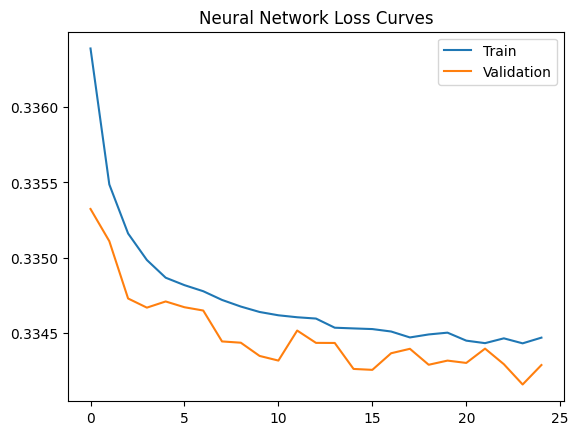

In [28]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Neural Network Loss Curves")
plt.show()

# Part 3: Model Evaluation & Interpretation  
## 3.1 Neural Network Test Set Evaluation

In [29]:
# 3.1 Neural Network - Test Set Evaluation

# Transform test data using the already-fitted preprocessor 
# using preprocessor_clf (fitted on training data), not re-fitting
X_test_transformed = preprocessor_clf.transform(X_clf_test)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_clf_test.values, dtype=torch.float32).view(-1, 1)

#  Get predictions from the trained NN 
model.eval()
nn_probs_list = []
nn_preds_list = []

with torch.no_grad():
    # Process in batches to avoid memory issues on large test set
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=256)
    
    for xb, _ in test_loader:
        logits = model(xb)
        probs = torch.sigmoid(logits).squeeze()
        preds = (probs >= 0.5).long()
        nn_probs_list.append(probs.numpy())
        nn_preds_list.append(preds.numpy())

nn_probs = np.concatenate(nn_probs_list)
nn_preds = np.concatenate(nn_preds_list)
y_test_np = y_clf_test.values

# Compute all classification metrics
nn_metrics = {
    "Model": "Neural Network",
    "Accuracy":  accuracy_score(y_test_np, nn_preds),
    "Precision": precision_score(y_test_np, nn_preds),
    "Recall":    recall_score(y_test_np, nn_preds),
    "F1":        f1_score(y_test_np, nn_preds),
    "AUC":       roc_auc_score(y_test_np, nn_probs)
}

print("Neural Network Test Performance:")
for k, v in nn_metrics.items():
    if k != "Model":
        print(f"  {k}: {v:.4f}")

Neural Network Test Performance:
  Accuracy: 0.5944
  Precision: 0.7991
  Recall: 0.6153
  F1: 0.6953
  AUC: 0.6037


#### Full Model Comparison Table (All Models)

In [30]:
models = {
    "Logistic Regression": log_reg_pipeline,
    "Random Forest (Tuned)": best_rf_clf
}

all_results = []
for name, mdl in models.items():
    m = evaluate_classification(mdl, X_clf_test, y_clf_test)
    m["Model"] = name
    all_results.append(m)

# Add Neural Network results
all_results.append(nn_metrics)

# Build and display the summary table
summary_df = pd.DataFrame(all_results)[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
].set_index("Model").round(4)

print("\n=== Full Model Comparison - Test Set ===")
print(summary_df.to_string())
summary_df



=== Full Model Comparison - Test Set ===
                       Accuracy  Precision  Recall      F1     AUC
Model                                                             
Logistic Regression      0.7534     0.7542  0.9970  0.8588  0.5914
Random Forest (Tuned)    0.7113     0.7708  0.8769  0.8204  0.5945
Neural Network           0.5944     0.7991  0.6153  0.6953  0.6037


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.7534,0.7542,0.9970,0.8588,0.5914
Random Forest (Tuned),0.7113,0.7708,0.8769,0.8204,0.5945
Neural Network,0.5944,0.7991,0.6153,0.6953,0.6037


## 3.2 ROC Curves

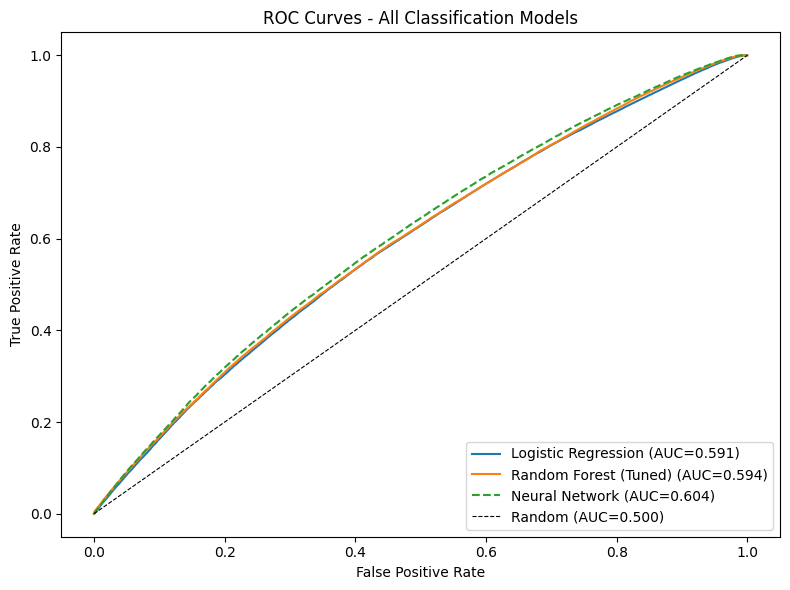

In [31]:
plt.figure(figsize=(8, 6))

# Sklearn models
for name, mdl in models.items():
    probs = mdl.predict_proba(X_clf_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_clf_test, probs)
    auc_score = roc_auc_score(y_clf_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test_np, nn_probs)
auc_nn = roc_auc_score(y_test_np, nn_probs)
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC={auc_nn:.3f})", linestyle='--')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label="Random (AUC=0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Classification Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 3.3 Confusion Matrix (Best Model)

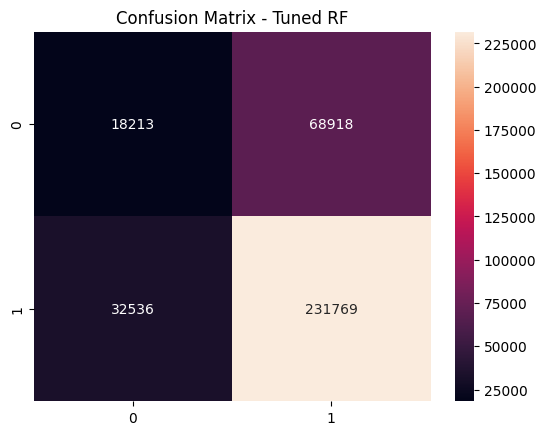

In [32]:
preds = best_rf_clf.predict(X_clf_test)
cm = confusion_matrix(y_clf_test, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Tuned RF")
plt.show()

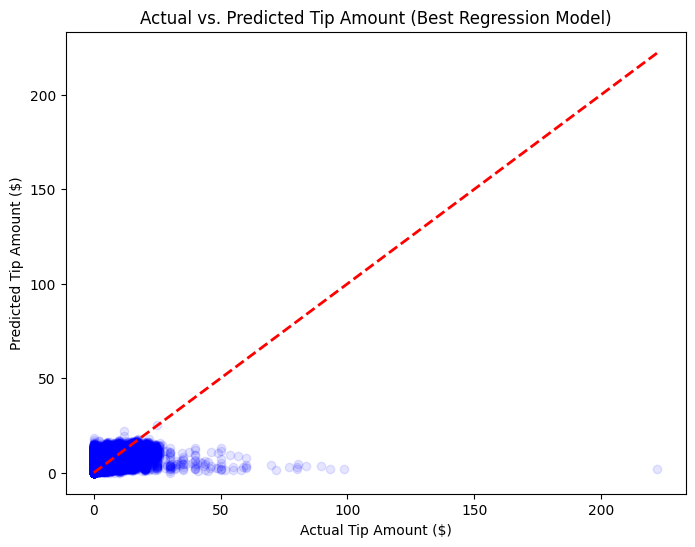

In [33]:
y_pred_log = rf_reg_pipeline.predict(X_reg_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_reg_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.1, color='blue')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.xlabel("Actual Tip Amount ($)")
plt.ylabel("Predicted Tip Amount ($)")
plt.title("Actual vs. Predicted Tip Amount (Best Regression Model)")
plt.show()

## 3.4 Residual Analysis (Regression)

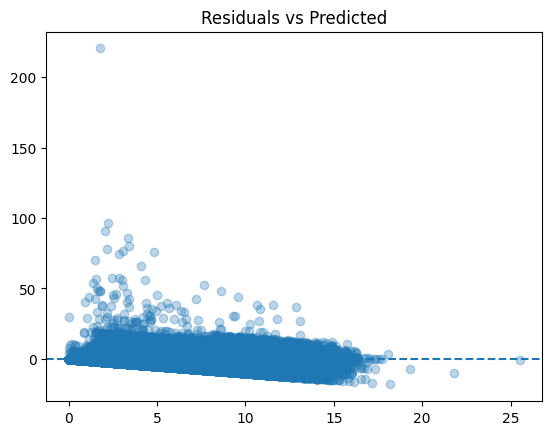

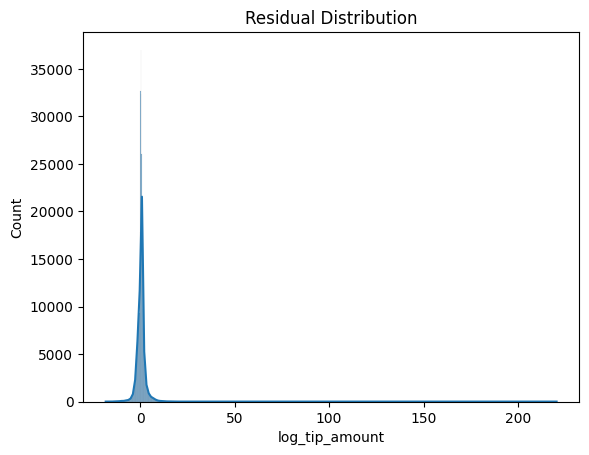

In [34]:
best_reg_model = rf_reg_pipeline

y_pred_log = best_reg_model.predict(X_reg_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_reg_test)

residuals = y_actual - y_pred

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted")
plt.show()

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

## 3.7 Model Coefficient Analysis 

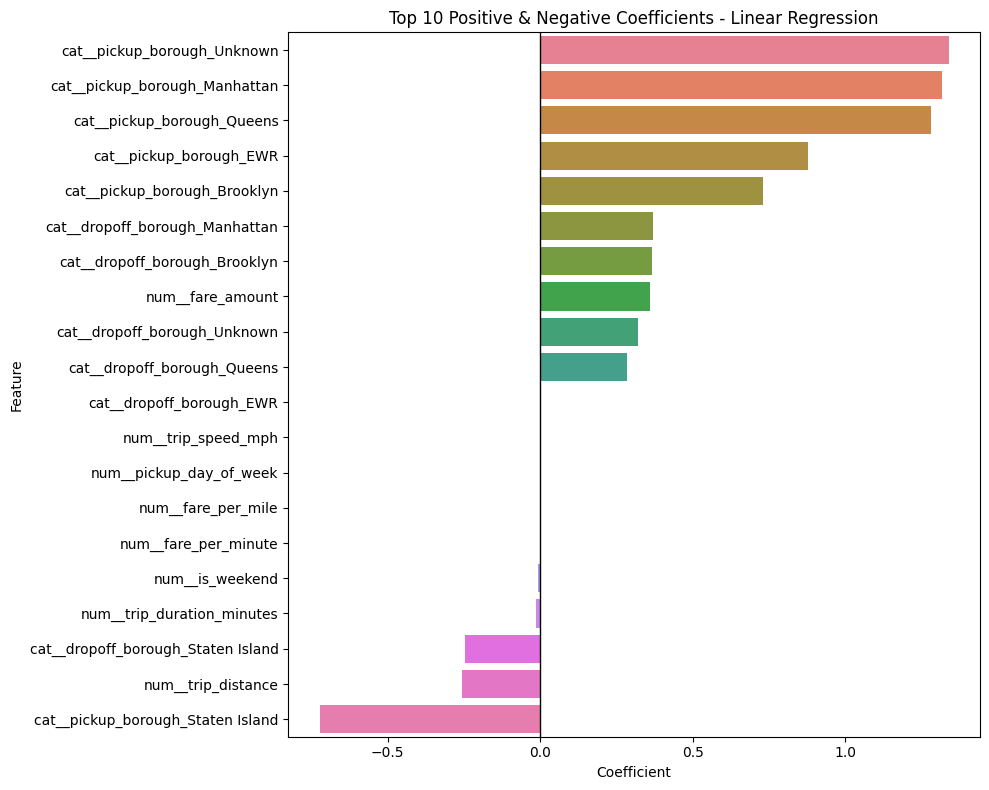

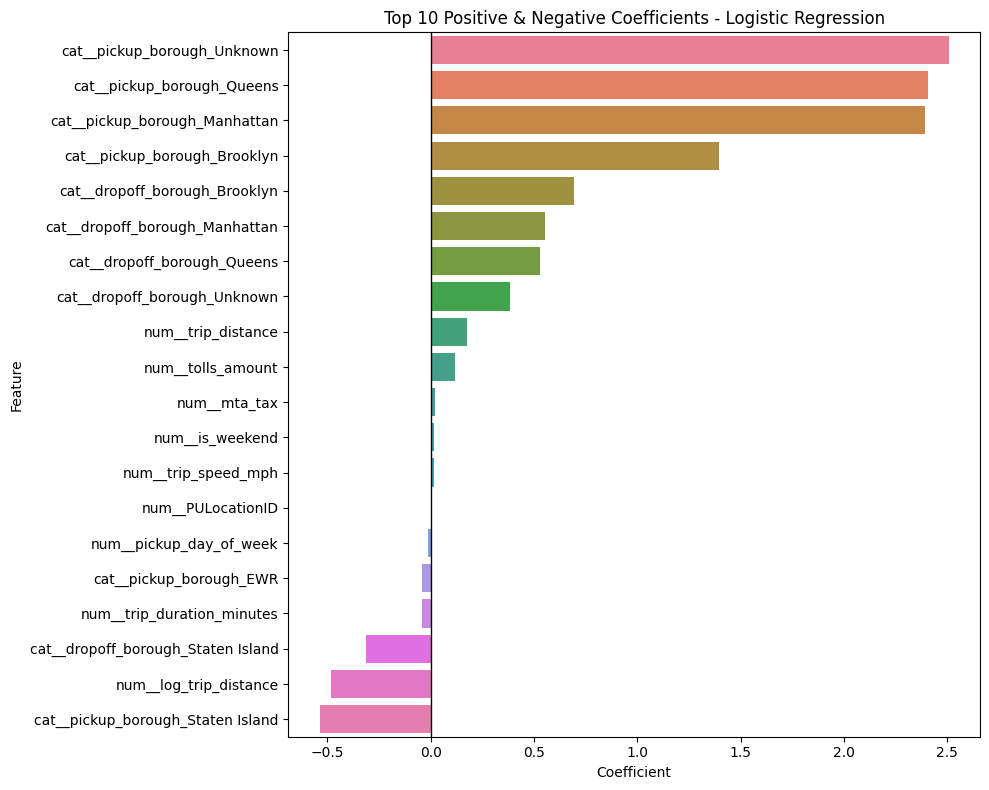

In [35]:

def plot_coefficients(model, name):
    # Extract feature names from the pipeline's preprocessor
    feat_names = model.named_steps['preprocessor'].get_feature_names_out()
    
    # Linear models store coefficients in .coef_
    coefs = model.named_steps['model'].coef_.flatten()
    
    coef_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': coefs})
    coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

    # UPDATED: Use pd.concat instead of .append()
    top_and_bottom = pd.concat([coef_df.head(10), coef_df.tail(10)])

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=top_and_bottom, hue='Feature', legend=False)
    plt.title(f"Top 10 Positive & Negative Coefficients - {name}")
    plt.axvline(0, color='black', linestyle='-', linewidth=1) # Adds a vertical line at 0 for clarity
    plt.tight_layout()
    plt.show()

# Run for both linear models
plot_coefficients(lin_reg_pipeline, "Linear Regression")
plot_coefficients(log_reg_pipeline, "Logistic Regression")

## 3.5 SHAP Explainability (Bonus)

Starting SHAP explainability...
Data prepared for SHAP
Explainer created
SHAP values computed


C:\Users\theda\AppData\Local\Temp\ipykernel_20448\1982893638.py:54: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\theda\AppData\Roaming\Python\Python313\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\theda\AppData\Roaming\Python\Python313\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


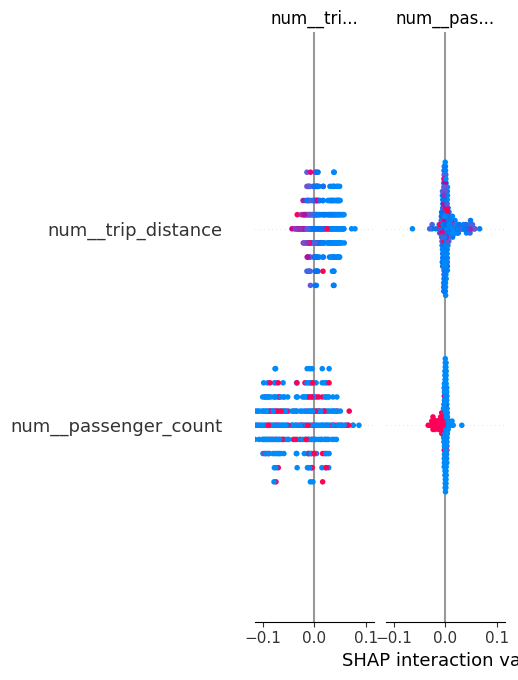

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (25, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [37]:
print("Starting SHAP explainability...")

# Extract model and preprocessor from the pipeline
rf_model = best_rf_clf.named_steps["model"]
preprocessor = best_rf_clf.named_steps["preprocessor"]


# Sample a small number of trips
# SHAP is expensive, so we explain only a small subset
X_sample_raw = X_clf_test.sample(300, random_state=42)
-
# Apply the trained preprocessing
X_sample = preprocessor.transform(X_sample_raw)

# Convert sparse matrix if necessary
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Data prepared for SHAP")

# Step 3: Create TreeExplainer
explainer = shap.TreeExplainer(rf_model)

print("Explainer created")

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification SHAP returns list
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values computed")

# Global Feature Importance Plot
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

# Explain 3 Individual Trips
# Create proper SHAP explanation object
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_sample,
    feature_names=feature_names
)

# Plot explanations for 3 trips
for i in range(3):
    shap.plots.waterfall(shap_exp[i, 1])  # fixed shap.plots.waterfall(shap_exp[i])

# Written Analysis

## 3.6 Written Analysis

#### Best Performing Models

##### Regression Task  
For the regression objective, predicting the absolute tip amount in dollars, the strongest model was Linear Regression. On the held-out test set it produced an MAE of 2.19 and an R² of 0.554. Performance was slightly stronger than the Random Forest Regressor, which recorded MAE 2.36 and R² 0.537.  

A simple linear estimator outperforming a tree ensemble may initially appear counterintuitive. In this dataset, it is not. The dominant explanatory variable is fare_amount, which remains in the feature set for the regression formulation. Taxi tipping in New York follows a widely internalised percentage convention. Payment terminals typically present passengers with suggested tips of 20%, 25%, and 30% of the fare, effectively anchoring the decision process to a proportional rule.  

The statistical implication is straightforward: the functional relationship between fare and tip is close to linear for most observations. A linear model therefore aligns closely with the true signal structure.  

Tree ensembles do not gain much leverage in such a setting. Random forests approximate functions using piecewise-constant partitions of feature space. That flexibility is advantageous when the underlying mapping is nonlinear or contains strong interactions. Here, the signal is largely monotonic and proportional. The forest therefore provides little additional explanatory power while introducing higher variance in prediction error, which slightly degrades RMSE.  

An R² of 0.554 indicates that approximately 55% of the observed variance in tip amounts is explained by the model. The remaining variation is attributable to factors not represented in the dataset: passenger disposition, driver behaviour, perceived trip quality, conversational dynamics, and other latent social variables.  

Those drivers are fundamentally unobserved. 

##### Classification Task  
The classification problem—predicting whether a trip receives a high tip (>20% of fare)—proved substantially harder. All three candidate models produced similar results, and overall discrimination was weak. The tuned Random Forest classifier achieved an AUC of 0.594, with Logistic Regression slightly behind at 0.591.  

Such values indicate limited predictive power. An AUC in the 0.59 range corresponds to only marginal improvement over random ordering of observations.  

Inspection of the full evaluation table shows the Neural Network achieving the highest AUC of the three models (0.604). At first glance, this appears inconsistent with its 59.4% accuracy, which is noticeably lower than the roughly 75% accuracy reported by the sklearn models. The discrepancy arises from the training objective rather than model quality.  

Specifically, the neural network was trained using BCEWithLogitsLoss with a pos_weight adjustment. This weighting scheme shifts the effective classification threshold away from the standard 0.5 probability cutoff in order to penalise false negatives more aggressively. Consequently, the resulting decision boundary differs from that used implicitly by the other models. Raw accuracy therefore ceases to be directly comparable.  

AUC becomes the appropriate metric because it measures ranking performance independent of the classification threshold. On that basis, the neural network is the strongest classifier in this experiment, though the margin is extremely small.  

The training dynamics provide additional evidence. Both training and validation losses converge rapidly and plateau at roughly 0.334 by epoch five, remaining essentially unchanged thereafter. The network reached its performance ceiling almost immediately. The limitation lies in the feature space, not in model capacity.

#### Most Predictive Features

In the regression setting, the Linear Regression coefficient plot reveals a clear geographic structure. Borough indicators dominate the model.

Trips originating in Manhattan, Queens, and EWR (Newark Airport) exhibit the largest positive coefficients. Even after controlling for fare, trip duration, and distance, these pickup zones are associated with higher expected tips. Staten Island shows the largest negative coefficient relative to the Bronx baseline, indicating systematically lower tipping behavior.

The feature fare_amount also retains a positive coefficient of meaningful magnitude, which reflects the previously discussed proportional tipping norm.

The spatial pattern is intuitively plausible. Manhattan and airport trips often involve tourists, business travelers, or passengers charging expenses to employers. These groups tend to follow suggested tipping norms more consistently and often round upward. Staten Island trips are more frequently taken by local residents conducting routine travel, where tipping practices may diverge from tourist-driven conventions.

A similar geographic pattern emerges in the classification model.  
The Logistic Regression coefficient plot shows the largest positive effects for pickup_borough_Unknown, pickup_borough_Queens, and pickup_borough_Manhattan. Again, Staten Island exhibits the strongest negative association with the probability of a high tip.

One coefficient is somewhat unexpected. The variable log_trip_distance carries a negative sign in the logistic model. In other words, longer trips slightly reduce the likelihood that the tip exceeds the 20% threshold.

A plausible behavioral explanation exists. For long trips, passengers may anchor on round dollar amounts rather than percentages when entering custom tips. The resulting tip may still be generous in absolute terms but may fall short of the percentage threshold used to define the positive class.

SHAP analysis reinforces the broader conclusion. The variables trip_distance and passenger_count appear as the most influential predictors by mean absolute SHAP value, yet the magnitudes are small—generally within ±0.1. The narrow contribution range indicates that no single feature exerts strong control over the classification decision. This diffuse signal explains the consistent AUC ceiling observed across models.

#### Limitations

##### Data leakage concerns  
A major design choice in the notebook concerns the treatment of monetary variables.  
For the regression task, features such as fare_amount, fare_per_mile, and fare_per_minute are retained as predictors. Their inclusion likely explains the relatively strong R² of 0.55, because fare functions as a near-direct proxy for tip under the percentage tipping norm.

In the classification formulation these variables are removed. The reason is straightforward: the label high_tip is defined relative to the fare value itself. Including fare in the feature set would introduce direct target leakage. The decision is methodologically correct. It also means that the regression and classification models operate under different information regimes, making their results not strictly comparable.  

Additional variables introduce a subtler issue. Features such as mta_tax, extra, tolls_amount, and the location identifiers PULocationID/DOLocationID are only known after the trip concludes. If the intended application were real-time prediction at passenger pickup, these variables would constitute forward-looking information. The current configuration should therefore be interpreted as post-trip modeling, not as a real-time predictive system.  

mta_tax, extra, tolls_amount, and PULocationID/DOLocationID are also included as features but are known only at trip completion, not at trip start. If the goal were real-time prediction of tips at the moment a passenger boards, these would also be leaky. The current setup is more accurately described as post-trip tip modelling than pre-trip prediction.  

##### Dataset biases  
The dataset covers January 2023 only, representing a single winter month. Seasonal variation in tourism, weather, and holiday travel patterns likely affects tipping distributions. For example, December holiday travel may exhibit different generosity patterns, while summer tourism may alter passenger demographics.

Another source of bias arises from payment filtering. The dataset restricts analysis to credit card transactions, excluding cash payments. Cash-paying passengers may have different socioeconomic profiles or tipping habits, which limits the external validity of the results. The model therefore generalizes only to card-paid taxi trips within the sampled time period.

##### Feature limitations   
Several potentially informative predictors are absent.
* Weather variables are the most obvious omission. Rainfall, temperature, and wind conditions influence both taxi demand and passenger mood; adverse weather may plausibly increase tipping behavior.
* Driver-level attributes are also unavailable. Driver experience, navigation efficiency, and interpersonal interaction could all influence tip outcomes.
* Passenger characteristics are similarly absent. No demographic indicators are provided, nor any information regarding promotional discounts or application-based fare adjustments.

The resulting feature space is therefore relatively sparse with respect to behavioral drivers.  

##### Model limitations
Residual diagnostics reveal heteroscedasticity in the regression model. Prediction error increases markedly as the true tip amount grows larger. Large tips are systematically underpredicted.

Predicted values cluster roughly in the $1–$5 range, even when observed tips reach $200 or more. This compression effect stems partly from the log-transformed target variable combined with a mean-squared error objective. The training process prioritizes accuracy in the dense low-tip region, where most observations lie, at the expense of rare high-value tips.

Alternative approaches could address this imbalance. Quantile regression, or a specialized model for the upper tail of the distribution, would better capture the behavior of extreme values.

#### Potential Improvements

Given more time and data, the following improvements would be prioritised:  

##### Feature enrichment  
The most impactful improvements would likely come from expanding the feature set.
Weather data provides a clear opportunity. Hourly measurements of temperature, precipitation, and wind speed from NOAA could be joined to each trip using timestamp and pickup zone identifiers. Such environmental context may explain variation in both travel patterns and passenger generosity.

Another useful feature would be historical tipping averages by pickup zone. Incorporating a contextual statistic such as “average tip percentage for trips originating from this zone” would capture geographic baseline effects more directly than simple one-hot encoding.  

##### Target engineering for regression  
The regression target could be reformulated. Rather than predicting tip_amount directly, the model could learn tip percentage defined as:

tip_pct = tip_amount/fare_amount  

Predictions could then be converted back to dollar values by multiplying the predicted percentage by the fare. This transformation separates trip cost effects from passenger generosity, potentially improving interpretability and statistical efficiency.

##### Improved classification framing  
The current binary threshold of 20% yields a 75/25 class distribution, with “high tip” as the majority class. This definition may not be optimal. Alternative thresholds could be explored, or the task could be reframed as a multi-class problem distinguishing low, medium, and high tipping tiers. Such a formulation might produce predictions that are more operationally useful.

Calibration techniques should also be considered. Applying Platt scaling or isotonic regression to classifier outputs would improve the reliability of predicted probabilities, which currently appear poorly calibrated given the near-random AUC values.

##### Neural network improvements  
The neural architecture itself is adequate for the present feature space. However, richer inputs would justify additional architectural sophistication. Training could incorporate a learning rate scheduler—for example, cosine annealing or step decay—to allow the optimizer to escape early convergence plateaus.

High-cardinality categorical variables such as PULocationID (265 unique zones) would also benefit from embedding layers rather than raw integer encoding. Learned embeddings enable the network to capture latent spatial relationships between zones, which traditional encodings cannot represent effectively.

#### Neural Network vs Traditional ML: A Comparison

For this dataset—structured tabular data with a modest number of predictors and relatively weak signal strength—traditional machine learning models perform as well as or better than the neural network. The underlying reason is simple. The predictive signal itself is limited. Regardless of model family, the classification task appears to have an AUC ceiling near 0.60. No algorithm can exceed the informational content of the features provided. In such circumstances, additional model complexity offers little benefit.

Neural networks become advantageous when richer input modalities are available. For example, GPS trajectory sequences, passenger application interaction logs, or temporal behavioral histories would introduce structured data that neural architectures can exploit. Sequence models such as LSTMs or attention-based architectures could extract patterns from those inputs that tree-based methods cannot easily represent.

With the current tabular feature set, however, the neural network’s additional parameters, training overhead, and hyperparameter sensitivity offer minimal return relative to simpler approaches such as Logistic Regression or a well-tuned Random Forest.

The training curves support this interpretation. Both training and validation losses stabilize within approximately five epochs, remaining effectively unchanged for the remainder of training. The network extracted all available signal from the features almost immediately. This behavior is diagnostic. The constraint is not architectural capacity. The constraint is the feature space itself.

## AI Usage Disclosure

Artificial intelligence tools were used during the development of this assignment strictly as support tools for clarification, debugging, and refinement. The primary tools used were ChatGPT, Gemini, Claude, and Grammarly. These explanations were used to strengthen conceptual understanding before implementation, identifying technical issues, and improving clarity of documentation. All code was executed, tested, and validated manually by the author, and all final implementation decisions were made independently.

### 1. Conceptual Clarification (ChatGPT referencing the course content)
- Clarifying data engineering concepts 
- Reviewing best machine learning best practices for regression and classification tasks 
- Strengthening understanding of evaluation metrics (MAE, RMSE, R², Accuracy, AUC)
- feature engineering strategies and dataset preparation techniques
- Drafting an initial solution


### 2. Debugging Assistance (Gemini and Claude)
- Resolve CPU and RAM crashes during large dataset processing
- Diagnosing compatibility issues caused by library version changes
- Improve efficiency of the data pipeline
- Improve correctness of data visualisations
- Assisting with troubleshooting SHAP implementation and interpretation (Claude)

All debugging suggestions were tested and validated manually before being integrated. 


### 3. Code Refactoring and Simplification
Gemini reviewed sections of code that were causing performance problems or excessive complexity.
- Suggesting more efficient implementations of data transformations and visualisation code.
- Reduce unnecessary complexity (bloated code was shortened and refined)
- Reviewing plotting functions to ensure compatibility with newer versions of Seaborn and Matplotlib 
- Ensuring inconsistent variable naming (Gemini and ChatGPT continually changed variable names)
- suggesting additional code and documentation to address requirements

All final code was reviewed, modified, and structured by the author.

 
### 4. Documentation and Report Refinement
Gemini was also used to perform a technical audit of the modeling approach. This included identifying potential issues such as:
- possible data leakage risks in feature transformations
- neural network convergence limitations based on observed loss curves
- classification bias caused by class imbalance
These recommendations were used as guidance for further investigation.  
 
Claude and Grammarly assisted with improving the clarity and structure of analytical explanations within the notebook. 
- interpreting regression and classification results
- describing SHAP feature importance outputs
- refining sections discussing limitations and potential improvements

All analytical conclusions were based on results produced by the author’s executed code, and the final text was manually reviewed and edited.


## What Was Done Independently (by the author)
- 90% of Comments
- Continued refinement of bloated code
- Ensuring consistent variable naming
- Implementation of all data cleaning rules and validation logic
- All feature engineering decisions (selection and implementation)
- Execution and verification of outputs
- Interpretation of analytical results
- Final performance optimizations

All outputs were executed locally, manually executed, verified, and validated before submission.


## Academic Integrity Statement  
AI tools were used only as development aids and learning assistants during the creation of this assignment.  

All suggestions generated by AI systems were treated as proposed solutions rather than final answers. Every code change, modeling decision, and analytical claim was manually tested and verified within the development environment before being accepted.

In several cases, AI suggestions required modification or were rejected after testing due to incompatibility with the assignment requirements, library versions, or runtime constraints. The final implementation therefore reflects the author’s independent validation, debugging, and technical judgement rather than direct AI-generated outputs.

All final code, outputs, analytical interpretations, and architectural decisions reflect the author’s own understanding and were verified independently through manual execution and testing.
The submission represents the author’s own work in compliance with academic integrity guidelines.